# Rotten Tomatoes Sentiment Analysis

This notebook converts the assignment into a step-by-step workflow:
- load the Rotten Tomatoes dataset,
- apply a pre-trained Hugging Face sentiment analysis model,
- evaluate predictions on the first 1000 training samples using qualitative and quantitative analysis.

## 1. Install and Import Dependencies

We import the libraries needed for dataset loading, model inference, evaluation, tabular inspection, and plotting.

In [19]:
# If you are running in a fresh environment, uncomment the next line:
# !pip install -q datasets transformers scikit-learn pandas matplotlib

from datasets import load_dataset # This is used to load the Rotten Tomatoes dataset from Hugging Face Datasets
from transformers import pipeline # This is used to create a sentiment analysis pipeline using a pre-trained model
from sklearn.metrics import (
    accuracy_score, # This is used to calculate the accuracy of the model
    classification_report, # This is used to generate a detailed classification report
    confusion_matrix, # This is used to compute the confusion matrix
    ConfusionMatrixDisplay, # This is used to display the confusion matrix
)
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Inspect the Rotten Tomatoes Dataset

This uses the provided starter code to confirm the dataset structure and fields.

In [20]:
# Load the Rotten Tomatoes dataset
dataset = load_dataset("rotten_tomatoes") # This will download and load the dataset into a Hugging Face Dataset object

# Print the dataset information
print(dataset)

# Example: Accessing the training split
train_dataset = dataset["train"]

# Print the first example in the training set
print(train_dataset[0])

# Show label names for reference
label_names = train_dataset.features["label"].names
print("Label names:", label_names)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})
{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}
Label names: ['neg', 'pos']


## 3. Prepare a 1000-Sample Training Subset

To keep inference fast and aligned with the assignment, we use the first 1000 samples from the training split.

In [21]:
subset_size = 1000
train_subset = train_dataset.select(range(subset_size))

texts = train_subset["text"]
true_labels = train_subset["label"]

dataset_label_to_name = {i: name for i, name in enumerate(label_names)}

subset_df = pd.DataFrame({
    "text": texts,
    "label": true_labels,
})
subset_df["label_name"] = subset_df["label"].map(dataset_label_to_name)

print(f"Subset size: {len(train_subset)}")
subset_df.head()

Subset size: 1000


,text,label,label_name
0,the rock is destined to be the 21st century's ...,1,pos
1,"the gorgeously elaborate continuation of "" the...",1,pos
2,effective but too-tepid biopic,1,pos
3,if you sometimes like to go to the movies to h...,1,pos
4,"emerges as something rare , an issue movie tha...",1,pos


## 4. Load a Pre-trained Sentiment Analysis Model

We use `distilbert-base-uncased-finetuned-sst-2-english`, a common sentiment model from Hugging Face.

In [22]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_classifier = pipeline(
    "sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
)

test_text = "This movie was unexpectedly funny and heartfelt."
test_prediction = sentiment_classifier(test_text)
print("Test prediction:", test_prediction)

/home/fredc/miniconda3/envs/dl/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Test prediction: [{'label': 'POSITIVE', 'score': 0.9998703002929688}]


## 5. Run Inference on the Subset

We send the 1000 review texts through the model in batches and keep both predicted labels and confidence scores.

In [23]:
predictions = sentiment_classifier(texts, batch_size=32, truncation=True)

predicted_text_labels = [pred["label"] for pred in predictions]
confidence_scores = [pred["score"] for pred in predictions]

print(f"Generated {len(predictions)} predictions.")
predictions[:10]

Generated 1000 predictions.


[{'label': 'POSITIVE', 'score': 0.9998360872268677},
 {'label': 'POSITIVE', 'score': 0.9998277425765991},
 {'label': 'NEGATIVE', 'score': 0.9960036873817444},
 {'label': 'POSITIVE', 'score': 0.9998257756233215},
 {'label': 'POSITIVE', 'score': 0.9997782111167908},
 {'label': 'POSITIVE', 'score': 0.9998192191123962},
 {'label': 'POSITIVE', 'score': 0.9998753070831299},
 {'label': 'NEGATIVE', 'score': 0.984596312046051},
 {'label': 'POSITIVE', 'score': 0.997896671295166},
 {'label': 'POSITIVE', 'score': 0.9998527765274048}]

## 6. Map Predictions to Dataset Labels

The model outputs text labels such as `POSITIVE` and `NEGATIVE`, so we convert them to numeric labels matching the dataset convention.

In [24]:
model_to_dataset_label = {
    "NEGATIVE": 0,
    "POSITIVE": 1,
}

predicted_labels = [model_to_dataset_label[label] for label in predicted_text_labels]

comparison_df = pd.DataFrame({
    "text": texts,
    "true_label": true_labels,
    "predicted_label": predicted_labels,
    "predicted_sentiment": predicted_text_labels,
    "confidence": confidence_scores,
})

comparison_df["true_label_name"] = comparison_df["true_label"].map(dataset_label_to_name)
comparison_df["predicted_label_name"] = comparison_df["predicted_label"].map(dataset_label_to_name)

comparison_df.head()

,text,true_label,predicted_label,predicted_sentiment,confidence,true_label_name,predicted_label_name
0,the rock is destined to be the 21st century's ...,1,1,POSITIVE,0.999836,pos,pos
1,"the gorgeously elaborate continuation of "" the...",1,1,POSITIVE,0.999828,pos,pos
2,effective but too-tepid biopic,1,0,NEGATIVE,0.996004,pos,neg
3,if you sometimes like to go to the movies to h...,1,1,POSITIVE,0.999826,pos,pos
4,"emerges as something rare , an issue movie tha...",1,1,POSITIVE,0.999778,pos,pos


## 7. Inspect Sample Predictions

This gives a qualitative look at how the model behaves on real movie reviews.

In [25]:
sample_examples = comparison_df.sample(5, random_state=42)

for example_number, (_, row) in enumerate(sample_examples.iterrows(), start=1):
    preview = row["text"][:220].replace("\n", " ")
    print(f"Example {example_number}")
    print(f"Text: {preview}...")
    print(f"True label: {row['true_label_name']}")
    print(f"Predicted label: {row['predicted_label_name']}")
    print(f"Confidence score: {row['confidence']:.4f}")
    print("-" * 80)

Example 1
Text: greengrass has delivered an undoubted stylistic tour-de-force , and has managed elements such as sound and cinematography with skill...
True label: pos
Predicted label: pos
Confidence score: 0.9997
--------------------------------------------------------------------------------
Example 2
Text: barney has created a tour de force that is weird , wacky and wonderful ....
True label: pos
Predicted label: pos
Confidence score: 0.9999
--------------------------------------------------------------------------------
Example 3
Text: it's a brave attempt to tap into the heartbeat of the world , a salute to the universal language of rhythm and a zippy sampling of sounds ....
True label: pos
Predicted label: pos
Confidence score: 0.9998
--------------------------------------------------------------------------------
Example 4
Text: it may not be " last tango in paris " but . . ....
True label: pos
Predicted label: neg
Confidence score: 0.6440
---------------------------------------

## 8. Compute Evaluation Metrics

Now we move from qualitative inspection to quantitative evaluation using accuracy, precision, recall, and F1-score.

In [26]:
accuracy = accuracy_score(true_labels, predicted_labels)

print(f"Accuracy on the first {subset_size} training samples: {accuracy:.4f}")
print("\nClassification report:")
print(classification_report(true_labels, predicted_labels, target_names=label_names, digits=4))

num_errors = sum(t != p for t, p in zip(true_labels, predicted_labels))
print(f"Misclassified samples: {num_errors}")

Accuracy on the first 1000 training samples: 0.8880

Classification report:
              precision    recall  f1-score   support

         neg     0.0000    0.0000    0.0000         0
         pos     1.0000    0.8880    0.9407      1000

    accuracy                         0.8880      1000
   macro avg     0.5000    0.4440    0.4703      1000
weighted avg     1.0000    0.8880    0.9407      1000

Misclassified samples: 112


/home/fredc/miniconda3/envs/dl/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/fredc/miniconda3/envs/dl/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/fredc/miniconda3/envs/dl/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## 9. Visualize Errors with a Confusion Matrix

A confusion matrix helps show how often the model confuses negative and positive reviews.

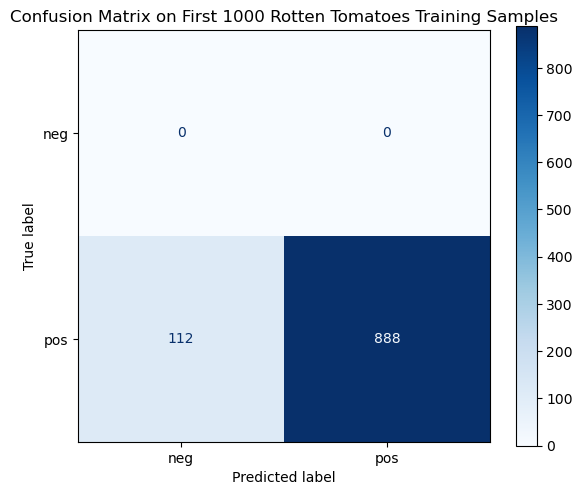

In [27]:
cm = confusion_matrix(true_labels, predicted_labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", values_format="d", ax=ax)
ax.set_title("Confusion Matrix on First 1000 Rotten Tomatoes Training Samples")
plt.tight_layout()
plt.show()

### Interpretation of the Confusion Matrix

The plot shows that, on these 1000 samples, the model correctly predicted **888 positive reviews** and incorrectly labeled **112 positive reviews as negative**. There are **no true negative or false positive counts** in this matrix, which suggests this particular subset contains only positive examples. 

This means the chart mainly reflects how well the model recognizes the **positive class** in this subset, rather than giving a fully balanced view of performance across both sentiment classes.